<a href="https://colab.research.google.com/github/gitnao95/Projets-Analyse-de-donnees/blob/main/Projet_Analyse_Relevebancaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET DE NETTOYAGE ET D'ANALYSE DE DONNEES FINANCIERES : RELEVE  BANCAIRE D'UN CLIENT
## DESCRIPTION DE LA BASE DE DONNEES : 309 lignes représentant les opérations ou transactions bancaires et 5 colonnes correspondant aux détails de chaque transaction tels que sa date, son libellé, son montant, sa catégorie.
### OBJECTIF DU PROJET : Ce projet consiste à nettoyer la Base de donnée, réaliser des études statistiques univariée et bivariée sur la BDD pour étudier les tendances de consommation du client.

#Nettoyage de données

In [106]:
#Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [107]:
#Charger les donnees
data = pd.read_csv('operations.csv')
data.head(10)

,date_operation,libelle,montant,solde_avt_ope,categ
0,2023-03-31,DON XX XX XX XX XX XX XX,-1.44,1515.25,AUTRE
1,2023-04-03,CARTE XX XX RAPT XX,-24.00,1513.81,TRANSPORT
2,2023-04-03,CARTE XX XX RAPT XX,-73.00,1489.81,TRANSPORT
3,2023-04-03,VIREMENT XX XX XX XX XX XX XX XX XX XX XX XX,676.00,1416.81,AUTRE
4,2023-04-03,VIREMENT XX XX XX XX XX XX,4.80,2092.81,AUTRE
5,2023-04-03,CARTE XX XX XX XX,-14.39,2097.61,AUTRE
6,2023-04-05,CARTE XX XX XX XX XX,-15.20,2083.22,AUTRE
7,2023-04-05,CARTE XX XX XX XX,-12.00,2068.02,AUTRE
8,2023-04-05,PRELEVEMENT XX TELEPHONE XX XX,-7.02,2056.02,FACTURE TELEPHONE
9,2023-04-05,CARTE XX XX LES ANCIENS ROBINSON XX,-6.80,2049.00,COURSES


## Analyses preliminaires

In [108]:
#Dimension de la BDD
data.shape

(309, 5)

In [109]:
#Verifier les Types de données et manquants
#data.dtypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date_operation  309 non-null    object 
 1   libelle         309 non-null    object 
 2   montant         307 non-null    float64
 3   solde_avt_ope   309 non-null    float64
 4   categ           308 non-null    object 
dtypes: float64(2), object(3)
memory usage: 12.2+ KB


In [110]:
#Date_operation n'est pas au bon format
data['date_operation'] = pd.to_datetime(data['date_operation'])

In [111]:
#Description de la BDD
data.describe()

,date_operation,montant,solde_avt_ope
count,309,307.000000,309.000000
mean,2023-07-05 05:26:12.815534080,-45.911889,3396.117799
min,2023-03-31 00:00:00,-15000.000000,1416.810000
25%,2023-05-19 00:00:00,-20.495000,3010.760000
50%,2023-07-05 00:00:00,-9.600000,3453.960000
75%,2023-08-21 00:00:00,-2.710000,3783.860000
max,2023-10-06 00:00:00,1071.600000,4709.310000
std,NaN,874.240605,666.180280


In [112]:
#Inclure toutes les variables dans la description
data.describe(include='all')

,date_operation,libelle,montant,solde_avt_ope,categ
count,309,309,307.000000,309.000000,308
unique,NaN,30,NaN,NaN,7
top,NaN,CARTE XX XX XX XX XX,NaN,NaN,AUTRE
freq,NaN,68,NaN,NaN,212
mean,2023-07-05 05:26:12.815534080,NaN,-45.911889,3396.117799,NaN
min,2023-03-31 00:00:00,NaN,-15000.000000,1416.810000,NaN
25%,2023-05-19 00:00:00,NaN,-20.495000,3010.760000,NaN
50%,2023-07-05 00:00:00,NaN,-9.600000,3453.960000,NaN
75%,2023-08-21 00:00:00,NaN,-2.710000,3783.860000,NaN
max,2023-10-06 00:00:00,NaN,1071.600000,4709.310000,NaN


##Valeurs manquantes


In [113]:
#Valeurs manquantes
missing_values = data.isnull().sum()
missing_values

,0
date_operation,0
libelle,0
montant,2
solde_avt_ope,0
categ,1


In [114]:
#Afficher les variables qui ont des manquants
missing_values[missing_values>0]

,0
montant,2
categ,1


In [115]:
#Afficher les lignes de montant qui manquent
data[data['montant'].isnull()]
#data.loc[data['montant'].isnull(),:]

,date_operation,libelle,montant,solde_avt_ope,categ
107,2023-06-12,CARTE XX XX LES ANCIENS ROBINSON XX,NaN,4667.19,COURSES
269,2023-09-11,CARTE XX XX XX XX,NaN,3401.93,AUTRE


In [116]:
#Vu que les operations sont dans l'ordre chronologique, on peut a partir du solde de l'opé déduire le montant débité pour chacune des opé
#stocker le df des valeurs manquantes dans un nouveau df
data_na = data.loc[data['montant'].isnull(),:]

#pour chaque ligne du df on recupere les index (elles ne changent pas grace au .loc)
for index in data_na.index:
  data.loc[index, 'montant'] = data.loc[index+1, 'solde_avt_ope'] - data.loc[index, 'solde_avt_ope']

#verifier
data.isnull().sum()

,0
date_operation,0
libelle,0
montant,0
solde_avt_ope,0
categ,1


In [117]:
#Verifier les lignes modifiées
data.loc[107]
#data.loc[269]

,107
date_operation,2023-06-12 00:00:00
libelle,CARTE XX XX LES ANCIENS ROBINSON XX
montant,-26.58
solde_avt_ope,4667.19
categ,COURSES


In [118]:
#Afficher les lignes de categorie qui manquent
data[data['categ'].isnull()]
#data.loc[data['categ'].isnull(),:]

,date_operation,libelle,montant,solde_avt_ope,categ
156,2023-07-06,PRELEVEMENT XX TELEPHONE XX XX,-36.48,3295.68,NaN


In [119]:
#Remplacer les lignes de categ qui manque
#Essayons de trouver la categorie qui correspond à ce libelle
data.loc[data['libelle'] == 'PRELEVEMENT XX TELEPHONE XX XX', :]

,date_operation,libelle,montant,solde_avt_ope,categ
8,2023-04-05,PRELEVEMENT XX TELEPHONE XX XX,-7.02,2056.02,FACTURE TELEPHONE
62,2023-05-09,PRELEVEMENT XX TELEPHONE XX XX,-7.02,4090.10,FACTURE TELEPHONE
102,2023-06-07,PRELEVEMENT XX TELEPHONE XX XX,-6.38,4688.91,FACTURE TELEPHONE
156,2023-07-06,PRELEVEMENT XX TELEPHONE XX XX,-36.48,3295.68,NaN
204,2023-08-07,PRELEVEMENT XX TELEPHONE XX XX,-7.46,3751.73,FACTURE TELEPHONE
260,2023-09-05,PRELEVEMENT XX TELEPHONE XX XX,-6.38,3453.96,FACTURE TELEPHONE
308,2023-10-06,PRELEVEMENT XX TELEPHONE XX XX,-13.58,2413.58,FACTURE TELEPHONE


In [120]:
#Remplacer la valeur manquante par facture telephone qui est la bonne categorie
data.loc[data['categ'].isnull(), 'categ'] = 'FACTURE TELEPHONE'
#verifier
data.isnull().sum()

,0
date_operation,0
libelle,0
montant,0
solde_avt_ope,0
categ,0


In [121]:
#Verifier la ligne modifiée
data.loc[156]

,156
date_operation,2023-07-06 00:00:00
libelle,PRELEVEMENT XX TELEPHONE XX XX
montant,-36.48
solde_avt_ope,3295.68
categ,FACTURE TELEPHONE


In [122]:
data.describe(include='all')

,date_operation,libelle,montant,solde_avt_ope,categ
count,309,309,309.000000,309.000000,309
unique,NaN,30,NaN,NaN,7
top,NaN,CARTE XX XX XX XX XX,NaN,NaN,AUTRE
freq,NaN,68,NaN,NaN,212
mean,2023-07-05 05:26:12.815534080,NaN,-45.739579,3396.117799,NaN
min,2023-03-31 00:00:00,NaN,-15000.000000,1416.810000,NaN
25%,2023-05-19 00:00:00,NaN,-20.590000,3010.760000,NaN
50%,2023-07-05 00:00:00,NaN,-9.600000,3453.960000,NaN
75%,2023-08-21 00:00:00,NaN,-2.720000,3783.860000,NaN
max,2023-10-06 00:00:00,NaN,1071.600000,4709.310000,NaN


##Doublons


In [123]:
#Gerer les doublons
#data[data.duplicated()]
data.loc[data[['date_operation', 'libelle', 'montant', 'solde_avt_ope']].duplicated(keep=False),:]

,date_operation,libelle,montant,solde_avt_ope,categ
43,2023-04-25,CARTE XX XX LES ANCIENS ROBINSON XX,-32.67,3647.67,COURSES
44,2023-04-25,CARTE XX XX LES ANCIENS ROBINSON XX,-32.67,3647.67,COURSES


In [124]:
#Supprimer la ligne doublon
#data.drop_duplicates(inplace=True)
data.drop_duplicates(subset=['date_operation', 'libelle', 'montant', 'solde_avt_ope'], inplace=True, ignore_index=True)

In [125]:
#Verifier les doublons
#data[data.duplicated()]
data.loc[data[['date_operation', 'libelle', 'montant', 'solde_avt_ope']].duplicated(keep=False),:]

,date_operation,libelle,montant,solde_avt_ope,categ


##Outliers

In [126]:
#Un describe peut aider à voir quelques outliers max et min
data.describe()

,date_operation,montant,solde_avt_ope
count,308,308.000000,308.000000
mean,2023-07-05 10:59:13.246753280,-45.782013,3395.301071
min,2023-03-31 00:00:00,-15000.000000,1416.810000
25%,2023-05-21 06:00:00,-20.447500,3010.737500
50%,2023-07-05 12:00:00,-9.600000,3452.465000
75%,2023-08-21 00:00:00,-2.715000,3787.232500
max,2023-10-06 00:00:00,1071.600000,4709.310000
std,NaN,872.818105,667.109412


In [127]:
#Voir la ligne de l'outlier
data[data['montant'] == -15000]

,date_operation,libelle,montant,solde_avt_ope,categ
198,2023-08-03,CARTE XX XX XX XX,-15000.0,3797.35,AUTRE


In [128]:
#Regardons les soldes avant et apres ce montant
#recuperer l'index de la ligne de l'outlier
#index_outlier = data[data['montant'] == -15000].index
#ou
index_outlier = data.loc[data['montant'] == -15000, :].index[0]
#voir les transactions autour
data.loc[index_outlier-1:index_outlier+1, :]

,date_operation,libelle,montant,solde_avt_ope,categ
197,2023-08-03,VIREMENT XX XX XX XX XX XX XX XX XX XX XX XX,676.00,3121.35,AUTRE
198,2023-08-03,CARTE XX XX XX XX,-15000.00,3797.35,AUTRE
199,2023-08-03,CARTE XX XX L'EPICERIE DEMBAS XX XX,-10.51,3782.96,AUTRE


In [129]:
#Remplacer ce montant d'operation
#Apres calcul sur les montants avant operation et depenses, on trouve le bon montant
data.loc[data['montant'] == -15000, 'montant'] = -14.39

In [130]:
#Verifier
#data[data['montant'] == -14.39]
data.describe(include='all')

,date_operation,libelle,montant,solde_avt_ope,categ
count,308,308,308.000000,308.000000,308
unique,NaN,30,NaN,NaN,7
top,NaN,CARTE XX XX XX XX XX,NaN,NaN,AUTRE
freq,NaN,68,NaN,NaN,212
mean,2023-07-05 10:59:13.246753280,NaN,2.872565,3395.301071,NaN
min,2023-03-31 00:00:00,NaN,-602.270000,1416.810000,NaN
25%,2023-05-21 06:00:00,NaN,-20.047500,3010.737500,NaN
50%,2023-07-05 12:00:00,NaN,-9.600000,3452.465000,NaN
75%,2023-08-21 00:00:00,NaN,-2.715000,3787.232500,NaN
max,2023-10-06 00:00:00,NaN,1071.600000,4709.310000,NaN


#Analyse univariée

##Variables qualitatives


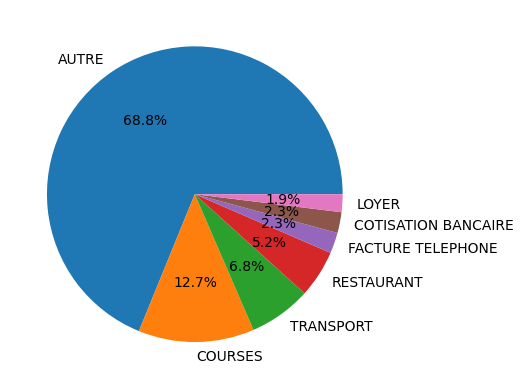

In [131]:
#representation de la variable Categ
#diagramme en secteur sur la variable categorie
frequence = data['categ'].value_counts()
categorie = frequence.index.tolist()
frequence = frequence.tolist()
plt.pie(frequence, labels= categorie, autopct='%1.1f%%')
plt.show()

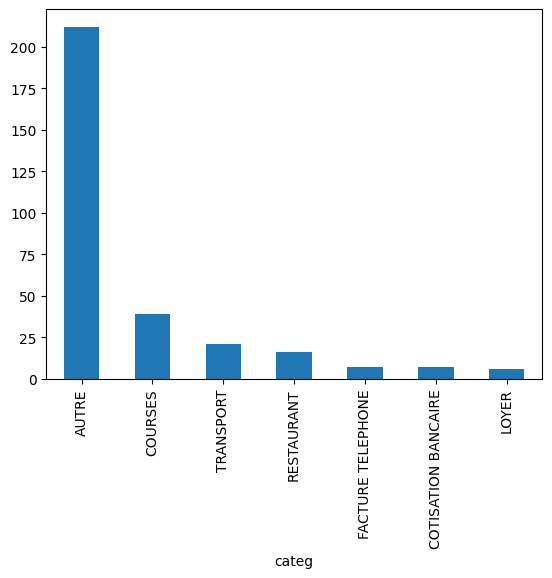

In [132]:
#diagramme en bar sur la variable categorie
data['categ'].value_counts().plot(kind='bar') #nombre
#sns.countplot(x=data['categ'])
#plt.xticks(rotation=90)
plt.show()
#data['categ'].value_counts(normalize=True).plot(kind='bar') #frequence

##Variables quantitatives

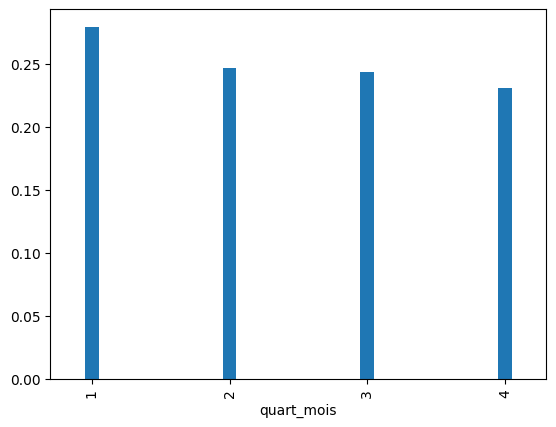

In [133]:
#Variable quantitative discrète
#Representation des jours du mois
data['quart_mois'] = [int((jour-1)*4/31)+1 for jour in data['date_operation'].dt.day]

#Diagramme en baton
data["quart_mois"].value_counts(normalize=True).plot(kind='bar',width=0.1)
plt.show()

In [134]:
#Representation sous forme de tableau
effectifs = data["quart_mois"].value_counts()
modalites = effectifs.index # l'index de effectifs contient les modalités

# initialisation du tableau à partir des modalités
tab = pd.DataFrame(modalites, columns = ["quart_mois"])
#ajouter la colonne n des effectifs
tab["n"] = effectifs.values
#ajouter la colonne f des frequences
tab["f"] = tab["n"] / len(data) #
#tri
tab = tab.sort_values(by = "quart_mois")
# Calcule de frequence cumulée
tab["F"] = tab["f"].cumsum()
tab

,quart_mois,n,f,F
0,1,86,0.279221,0.279221
1,2,76,0.246753,0.525974
2,3,75,0.243506,0.769481
3,4,71,0.230519,1.000000


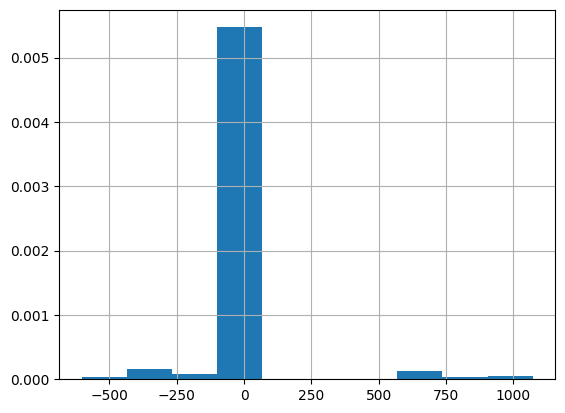

In [135]:
#Variable quantitative continue
#Representation de la variable montant Hist
data['montant'].hist(density=True)
plt.show()

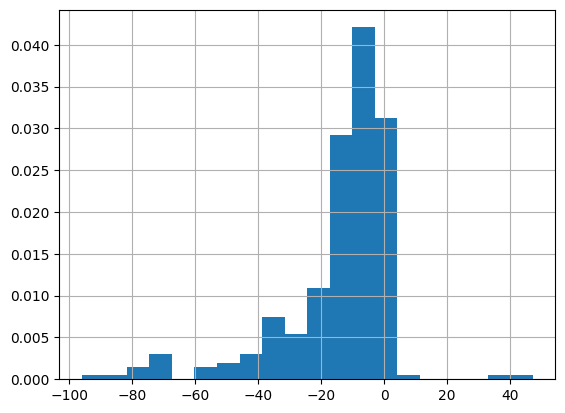

In [136]:
#Hist en filtrant sur les montants entre -100€ et 100€
data[data.montant.abs() < 100]["montant"].hist(density=True,bins=20)
plt.show()

####Mesures de tendances centrales

In [137]:
#Mesures de tendances centrales sur la variable montant
data['montant'].describe()

,montant
count,308.000000
mean,2.872565
std,176.089858
min,-602.270000
25%,-20.047500
50%,-9.600000
75%,-2.715000
max,1071.600000


In [138]:
#Mode
data['montant'].mode()

,montant
0,-1.6


Interpretation de la moyenne :

les montants des opérations sont très hétérogènes, avec des dépenses parfois trop elevées(exemple : Loyer) et souvent petites(exemple : téléphone). les entrées quant à elles sont peu fréquentes mais très grosses. Il est difficile d'interpreter la moyenne qui est sensible aux valeurs atypiques, ici elle vaut **2.87€**.

Interpretation de la mediane :

La médiane est de **-9.6€** ce qui veut dire que 50% des montants sont inferieurs à -9.6€ et 50% sont superieurs à -9.6€.
Cela nous montre aussi qu'il y a plus de depenses que d'entrées d'argent. Cependant les montants d'operations etant hétérogènes, il n'est pas très pertinent d'interpreter la mdédiane.

Interpretation du mode :

Le mode est de **-1.6€** ce qui nous indique que la plupart des opérations tournent autour de -1.6€.

Au final, ces 3 mesures sont très eloignées les unes des autres.
Pour étudier des montants d'operation plus homogènes, il serait donc interessant d'etudier chaque catégorie d'operation c'est à dire des opérations de meme nature.

AUTRE
La moyenne est :  23.433207547169808
La mediane est :  -8.31
Le mode est :  0   -1.6
Name: montant, dtype: float64


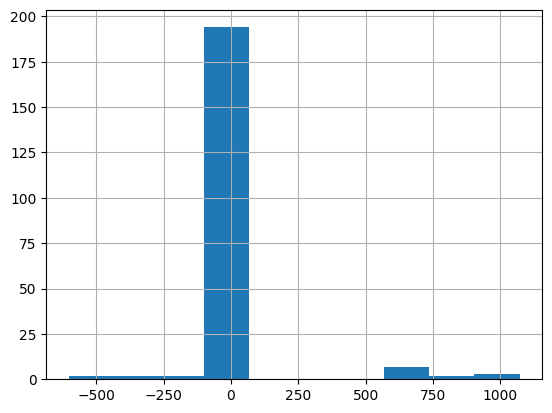

TRANSPORT
La moyenne est :  -52.99714285714286
La mediane est :  -53.1
Le mode est :  0   -73.0
Name: montant, dtype: float64


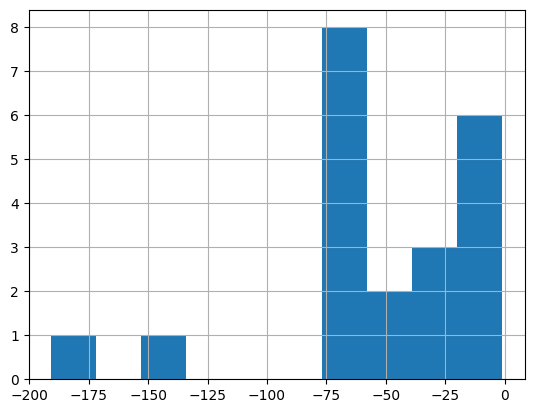

FACTURE TELEPHONE
La moyenne est :  -12.045714285714283
La mediane est :  -7.02
Le mode est :  0   -7.02
1   -6.38
Name: montant, dtype: float64


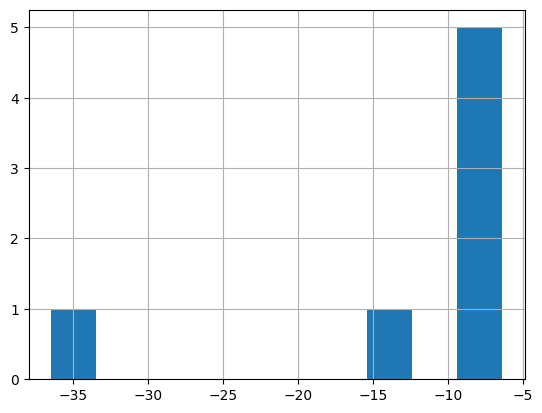

COURSES
La moyenne est :  -16.34128205128205
La mediane est :  -12.24
Le mode est :  0    -60.16
1    -42.45
2    -42.42
3    -33.55
4    -32.67
5    -29.18
6    -28.11
7    -27.68
8    -26.58
9    -26.19
10   -23.43
11   -22.59
12   -21.73
13   -20.59
14   -18.45
15   -17.16
16   -13.59
17   -12.96
18   -12.49
19   -12.24
20   -10.91
21   -10.36
22    -9.88
23    -9.60
24    -9.31
25    -9.11
26    -6.89
27    -6.80
28    -6.60
29    -5.88
30    -4.63
31    -4.41
32    -4.39
33    -3.48
34    -2.93
35    -2.56
36    -2.51
37    -1.90
38    -0.94
Name: montant, dtype: float64


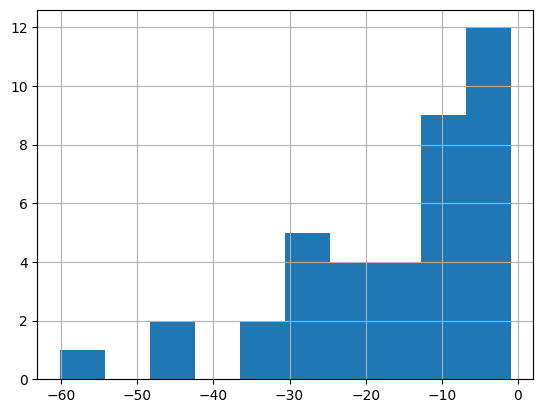

COTISATION BANCAIRE
La moyenne est :  -1.8857142857142857
La mediane est :  -1.92
Le mode est :  0   -1.92
Name: montant, dtype: float64


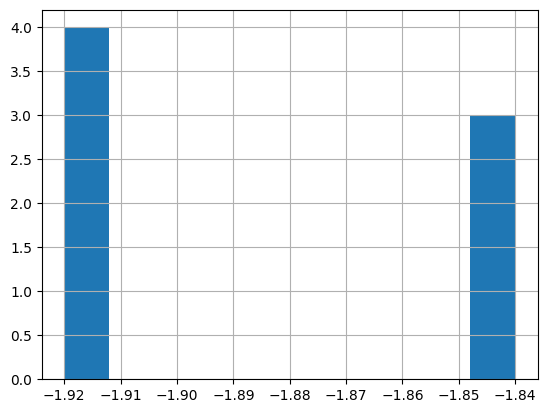

RESTAURANT
La moyenne est :  -10.3325
La mediane est :  -10.1
Le mode est :  0   -9.2
Name: montant, dtype: float64


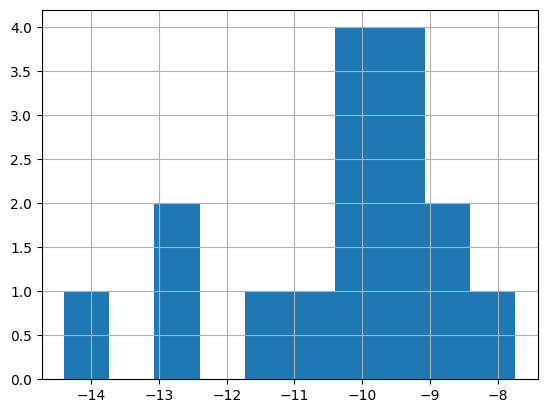

LOYER
La moyenne est :  -345.0
La mediane est :  -345.0
Le mode est :  0   -345.0
Name: montant, dtype: float64


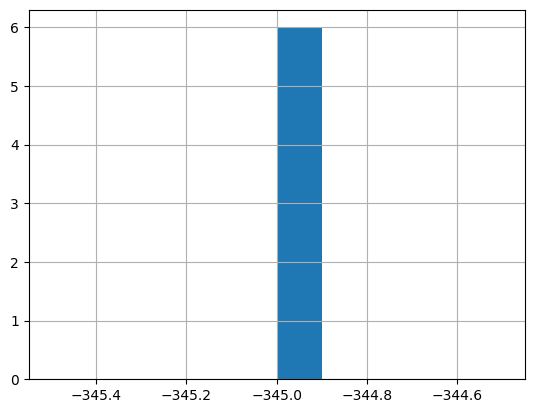

In [139]:
#Analyse des tendances centrales de la variable montant par categorie d'operation
for cat in data['categ'].unique():
  print(cat)
  print('La moyenne est : ', data[data['categ'] == cat]['montant'].mean())
  print('La mediane est : ', data[data['categ'] == cat]['montant'].median())
  print('Le mode est : ', data[data['categ'] == cat]['montant'].mode())
  data[data['categ'] == cat]['montant'].hist()
  plt.show()

####Mesures de dispersion
Nous ajoutons les mesures de dipersion à notre analyse pour étudier la variabilité des dépenses dans les différentes catégories et affiner nos interpretations.

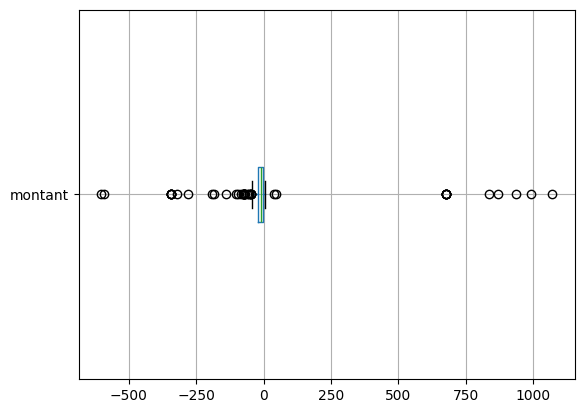

In [140]:
#Analyser la variable quantitative montant par boxplot
#montant
#sns.boxplot(x=data['montant'])
data.boxplot(column='montant', vert = False)
plt.show()

In [141]:
data[data['montant'] > 700]

,date_operation,libelle,montant,solde_avt_ope,categ,quart_mois
11,2023-04-07,VIREMENT XX XX XX XX XX XX XX XX XX XX,992.80,2040.36,AUTRE,1
21,2023-04-11,VIREMENT XX XX XX XX XX XX XX,836.00,2840.58,AUTRE,2
23,2023-04-11,VIREMENT XX XX XX XX XX XX XX,869.44,3669.02,AUTRE,2
81,2023-05-22,VIREMENT XX XX XX XX XX XX XX,936.32,3508.04,AUTRE,3
180,2023-07-25,VIREMENT XX XX XX XX XX XX XX,1071.60,2307.08,AUTRE,4


In [142]:
data[data['montant'] < -400]

,date_operation,libelle,montant,solde_avt_ope,categ,quart_mois
152,2023-07-03,CARTE XX XX XX XX XX XX XX XX,-602.27,3236.57,AUTRE,1
288,2023-09-25,PRELEVEMENT XX XX XX XX XX XX XX XX,-593.60,2898.75,AUTRE,4


Interpretation :
Les montants des opérations etant trop hétérogènes, nous allons les etudier par catégories.

AUTRE
La moyenne est :  23.433207547169808
La mediane est :  -8.31
Le mode est :  0   -1.6
Name: montant, dtype: float64
La variance est :  40401.82999254187
L ecart type est :  201.00206464746046


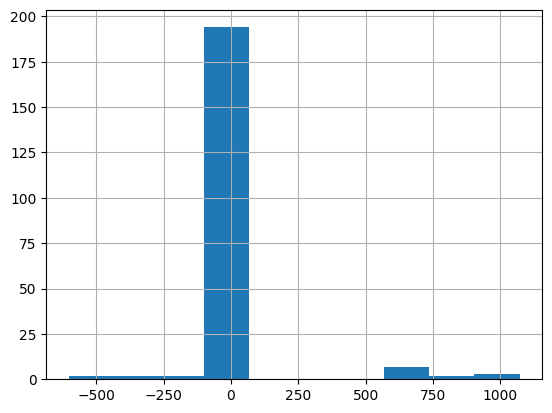

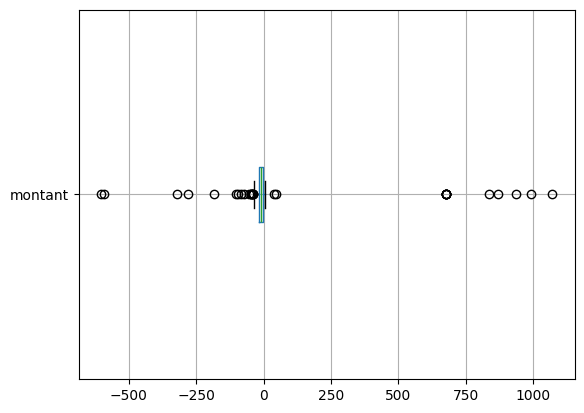

TRANSPORT
La moyenne est :  -52.99714285714286
La mediane est :  -53.1
Le mode est :  0   -73.0
Name: montant, dtype: float64
La variance est :  2205.016868027212
L ecart type est :  46.95760713694014


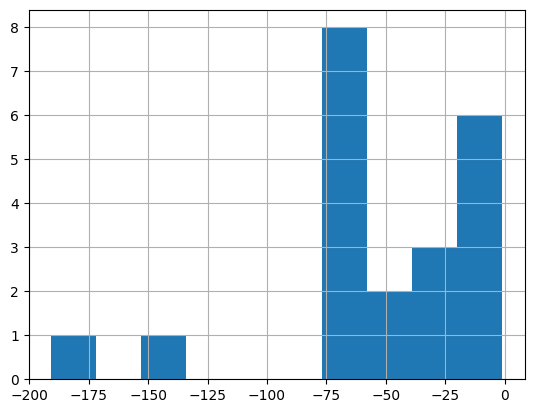

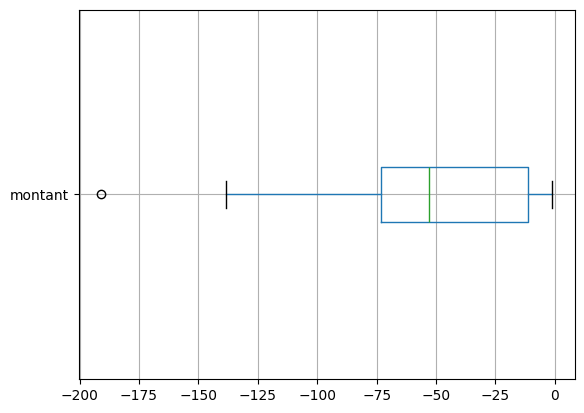

FACTURE TELEPHONE
La moyenne est :  -12.045714285714283
La mediane est :  -7.02
Le mode est :  0   -7.02
1   -6.38
Name: montant, dtype: float64
La variance est :  105.01905306122445
L ecart type est :  10.247880417980317


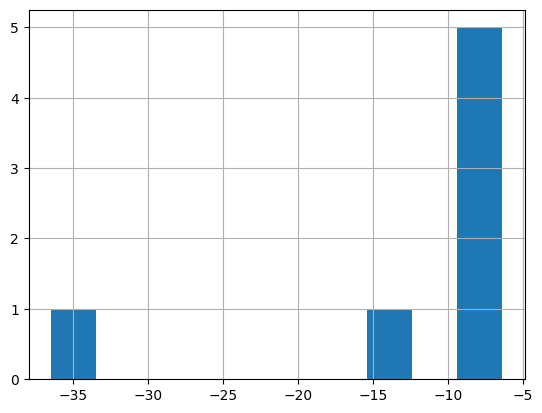

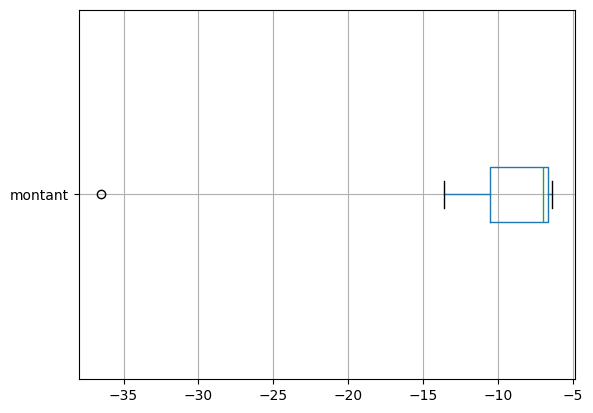

COURSES
La moyenne est :  -16.34128205128205
La mediane est :  -12.24
Le mode est :  0    -60.16
1    -42.45
2    -42.42
3    -33.55
4    -32.67
5    -29.18
6    -28.11
7    -27.68
8    -26.58
9    -26.19
10   -23.43
11   -22.59
12   -21.73
13   -20.59
14   -18.45
15   -17.16
16   -13.59
17   -12.96
18   -12.49
19   -12.24
20   -10.91
21   -10.36
22    -9.88
23    -9.60
24    -9.31
25    -9.11
26    -6.89
27    -6.80
28    -6.60
29    -5.88
30    -4.63
31    -4.41
32    -4.39
33    -3.48
34    -2.93
35    -2.56
36    -2.51
37    -1.90
38    -0.94
Name: montant, dtype: float64
La variance est :  177.02535476660088
L ecart type est :  13.3050875520081


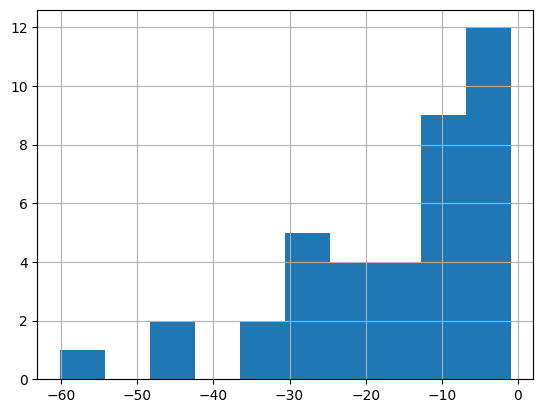

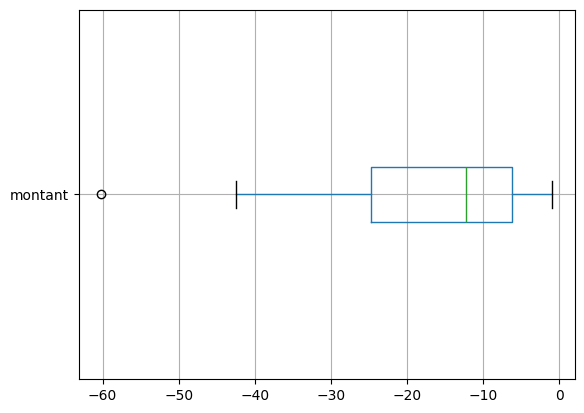

COTISATION BANCAIRE
La moyenne est :  -1.8857142857142857
La mediane est :  -1.92
Le mode est :  0   -1.92
Name: montant, dtype: float64
La variance est :  0.0015673469387755044
L ecart type est :  0.03958973274443141


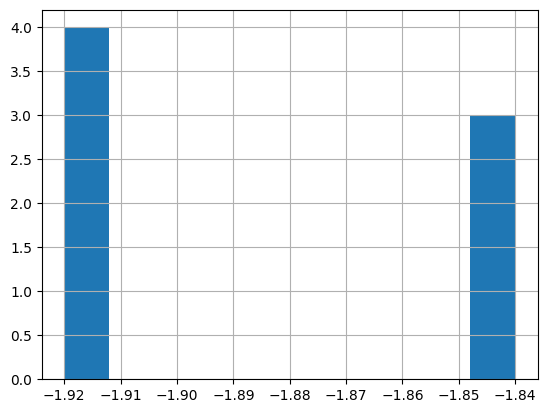

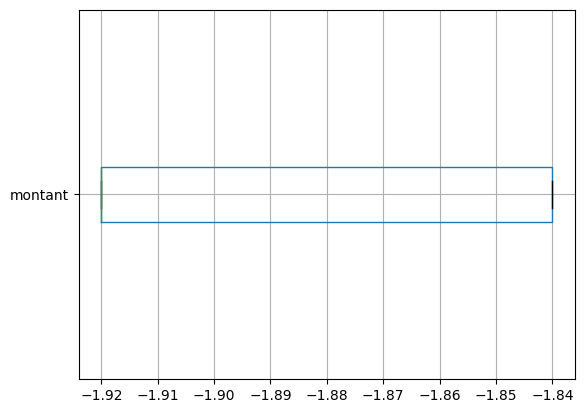

RESTAURANT
La moyenne est :  -10.3325
La mediane est :  -10.1
Le mode est :  0   -9.2
Name: montant, dtype: float64
La variance est :  2.853193750000001
L ecart type est :  1.689139943876765


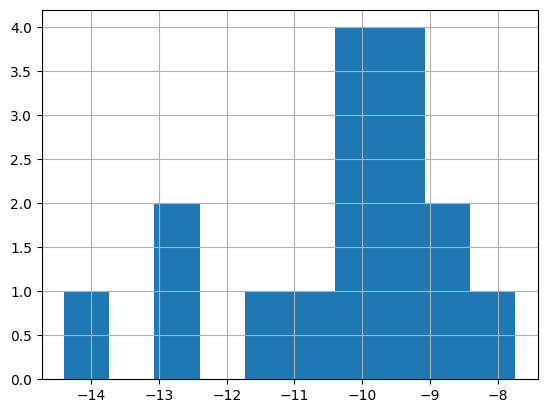

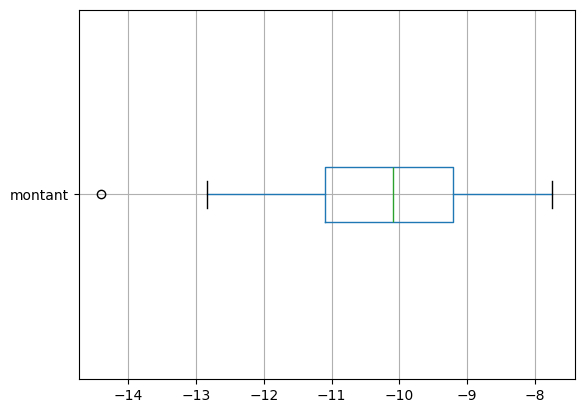

LOYER
La moyenne est :  -345.0
La mediane est :  -345.0
Le mode est :  0   -345.0
Name: montant, dtype: float64
La variance est :  0.0
L ecart type est :  0.0


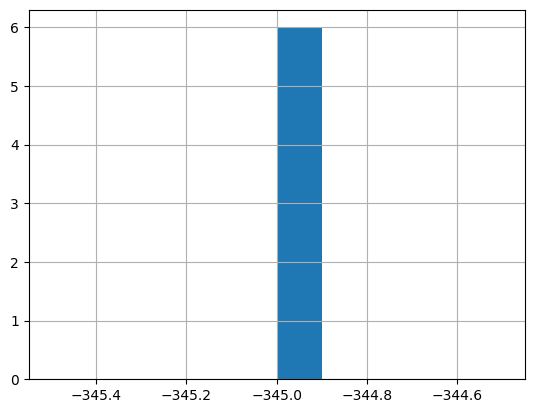

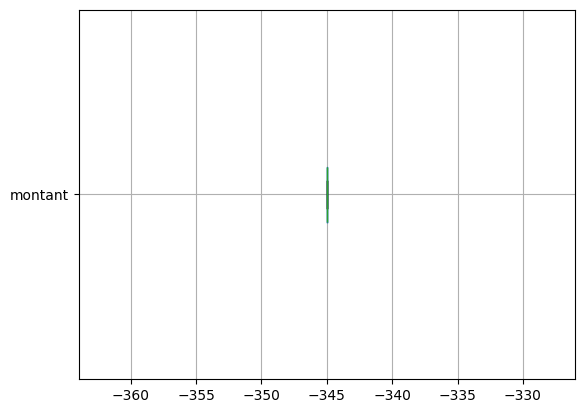

In [143]:
#Analyse de la variable montant par categorie d'operation ajouts des mesures de dispersion
for cat in data['categ'].unique():
  print(cat)
  print('La moyenne est : ', data[data['categ'] == cat]['montant'].mean())
  print('La mediane est : ', data[data['categ'] == cat]['montant'].median())
  print('Le mode est : ', data[data['categ'] == cat]['montant'].mode())
  print('La variance est : ', data[data['categ'] == cat]['montant'].var(ddof=0))
  print('L ecart type est : ', data[data['categ'] == cat]['montant'].std(ddof=0))
  data[data['categ'] == cat]['montant'].hist()
  plt.show()
  data[data['categ']==cat].boxplot(column='montant', vert = False)
  plt.show()

####INTERPRETATION DES GRAPHIQUES PAR CATEGORIES

- AUTRES : Il y a un écart important entre la moyenne (23.43) et la médiane (-8.31), la moyenne est beaucoup plus elevée que la médiane, ce qui suggère la présence de valeurs extrêmes (outliers) qui tirent la moyenne vers le haut. Ces valeurs extrêmes sont les opérations à montants positifs très élévées tels que les virements de salaire.  
Une médiane de -8.31 indique qu'au moins la moitié des opérations sont des dépenses. Le mode de -1.6 renforce l'idée que les montants négatifs sont fréquents dans cette catégorie.
La variance extremement élevée de 40401 confirme la présence d'une très grande variabilité (ou dispersion) dans les montants enregistrés dans cette catégorie.
Cela signifie que les dépenses AUTRES sont très irrégulières et imprévisibles. Les valeurs extremes en sont responsables. Il est possible de reclasser ces dépenses dans d'autres catégories plus adaptées, par exemple les virements de salaire pour réduire la variabilité.


- TRANSPORT : la moyenne (-52.99) et la médiane (-53.1) dans cette catégorie sont très proches, cela suggère que la distribution des montants pour les dépenses de transport est relativement plus symétrique que pour la précedente catégorie étudiée (AUTRES). En clair, il y a moins de valeurs extremes qui influencent la moyenne. On peut ajouter que la moyenne et la médiane sont négatives concluant que la plupart des opérations de cette catégorie sont des dépenses en frais de transport.
Le mode à -73 nous informe qu'il y a fréquemment des dépenses spécifiques à ce montant correspondant peut etre à un abonnement de transport en commun.
Les deux seuls valeurs élevées (-138 et -190), dont l'outlier à -190 pourraient correspondent à un abonnement de transport inter-regional.
La variance de 2205.02 indique une variabilité modérée des dépenses de transport : les dépenses varient mais pas de manière extreme.

- FACTURE TELEPHONE : la moyenne (-12.04) et la mediane (-7.02) montrent que les opérations dans cette catégorie sont majoritairement des dépenses, les modes (-7.02 & -6.38) confirment ce constat. La moyenne est plus éloignée de 0 que la médiane, ce qui indique la présence de valeur extrême négative qui tire la moyenne vers le bas. Vu la periode de facturation de cette dépense, la valeur extreme de -36.48 pourrait correspondre à des "hors-forfait" à l'etranger pendant des vacances par exemple. La présence de deux modes suggère qu'il existe deux types de montant de facturation fréquents ou un changement de tarification.
La variance de 105.02 indique une dispersion modérée des dépenses de téléphone : les dépenses varient mais pas de manière extreme.


- COURSES : La moyenne (-16.34) est plus éloignée de 0 que la médiane (-12.24), ce qui indique la présence de valeur extrême négative qui tire la moyenne vers le bas. Ici cette valeur est de -60.16 correspondant à une dépense plus élevée que d'habitude.
Notons que la présence de plusieurs modes est un phénomène interessant, cela signifie qu'il y a differents types de produit achetés à la meme fréquence.
La variance de 177.03 indique une dispersion modérée des dépenses de courses : les dépenses varient mais pas de manière extreme.


- COTISATION BANCAIRE : dans cette catégorie, la moyenne (-1.89) et la médiane (-1.92) sont très proches, la distribution des montants est très symétrique et il n'y a pas de outliers qui influencent la moyenne. La proximité de la moyenne, la mediane et le mode indique la régularité dans les cotisations bancaires : c'est un résultat attendu pour ce genre de frais.
Le mode à -1.92 suggère que ce montant revient le plus fréquemment.
Le passage de -1.84 à -1.92 de prélevement suggère une légère augmentation des frais bancaire.
La variance de 0.0016 montre qu'il n'y a quasiment pas de dispersion dans les montants depensés en cotisations bancaires.
Les données pour les cotisations bancaires montrent une très grande stabilité et une cohérence, ce qui est typique pour ce type de dépense.

- RESTAURANT : En moyenne, 10.33€ est dépensée au restaurant. La distribution des depenses au restaurant est relativement symétrique avec une moyenne (-10.33) très proche de la médiane (-10.1). Il n'y a qu'un seul outlier à -14.4 dans cette catégorie. Le mode à -9.2 indique que ce montant est le plus fréquent dans les dépenses au restaurant.
La variance de 2.85 indique une faible variabilité des dépenses au restaurant. Les dépenses au restaurants sont relativement constantes et prévisibles. Le mode proche de la moyenne et la mediane renforce l'idée que les dépenses au restaurant sont relativement stables.

- LOYER : La moyenne, la mediane et le mode sont tous égaux (-345), indiquant que les valeurs enregistrées pour le loyer sont identiques. Il n'y a pas de variation dans les montants de loyer : le montant du loyer est fixe. La variance nulle confirme l'absence totale de variablilité dans les montants de loyer.
Les données sont stables, previsibles et cohérentes.




####Mesures de formes
Nous ajoutons les mesures de formes telles que l'asymétrie et l'aplatissement de la distribution de nos variables pour affiner les interpretations.
- l'asymétrie mesure le degré d'asymétrie de la distribution.
Une asymétrie positive indique une queue de distribution plus longue à droite (valeurs extrêmes élevées).
Une asymétrie négative indique une queue de distribution plus longue à gauche (valeurs extrêmes faibles).
Une asymétrie proche de zéro indique une distribution symétrique.

- Le kurtosis mesure l'aplatissement de la distribution par rapport à une distribution normale.
Un kurtosis élevé indique une distribution avec des queues lourdes et des valeurs extrêmes plus fréquentes (leptokurtique).
Un kurtosis faible indique une distribution avec des queues légères et moins de valeurs extrêmes (platykurtique).
Un kurtosis proche de 3 indique une distribution normale (mésokurtique).

AUTRE
La moyenne est :  23.433207547169808
La mediane est :  -8.31
Le mode est :  0   -1.6
Name: montant, dtype: float64
La variance est :  40401.82999254187
L ecart type est :  201.00206464746046
L asymétrie est :  3.1215325222336423
L aplatissement est :  12.716537970826295


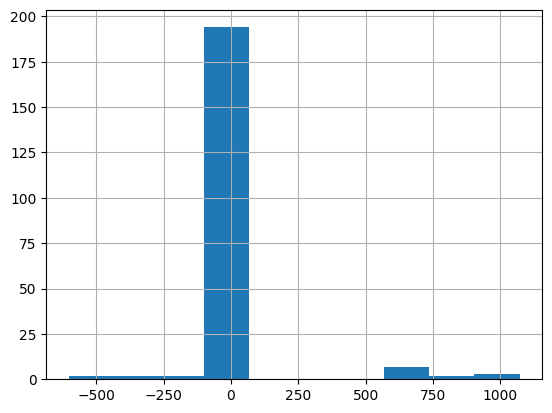

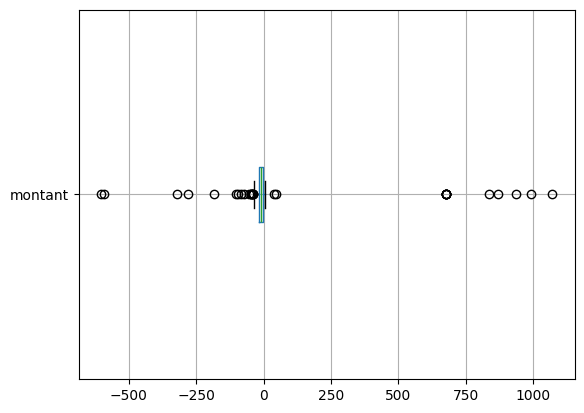

TRANSPORT
La moyenne est :  -52.99714285714286
La mediane est :  -53.1
Le mode est :  0   -73.0
Name: montant, dtype: float64
La variance est :  2205.016868027212
L ecart type est :  46.95760713694014
L asymétrie est :  -1.248265076217821
L aplatissement est :  2.1922705326917495


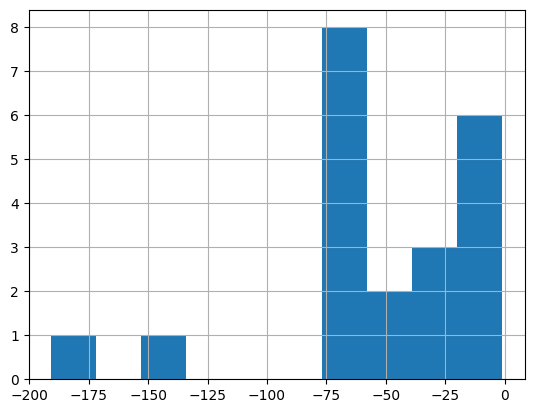

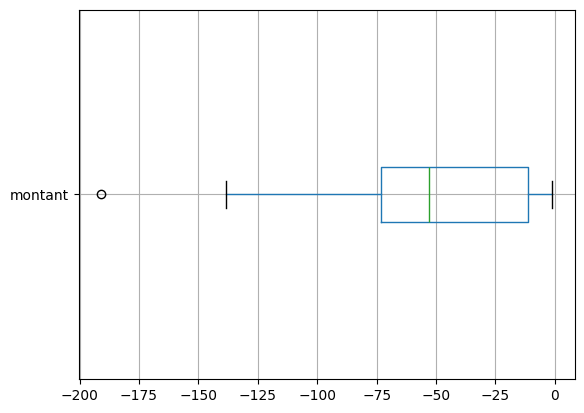

FACTURE TELEPHONE
La moyenne est :  -12.045714285714283
La mediane est :  -7.02
Le mode est :  0   -7.02
1   -6.38
Name: montant, dtype: float64
La variance est :  105.01905306122445
L ecart type est :  10.247880417980317
L asymétrie est :  -2.3876514564281526
L aplatissement est :  5.798563367885492


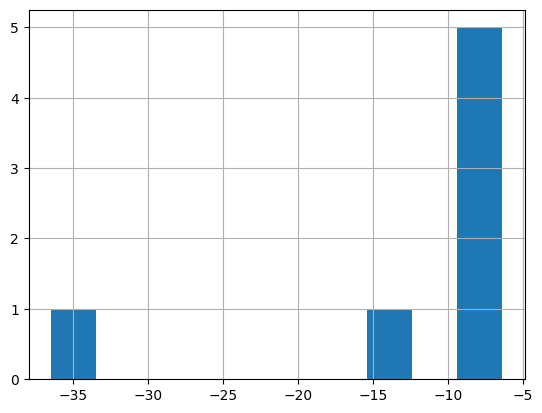

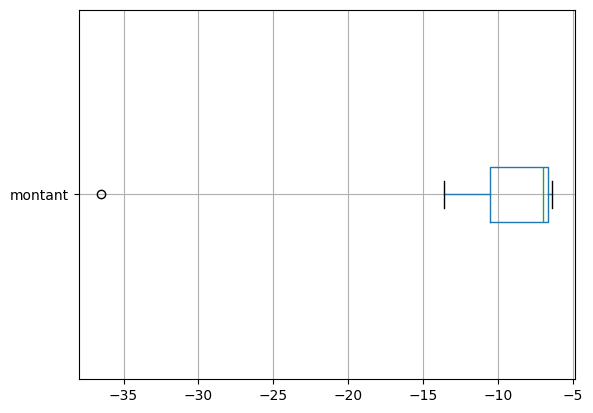

COURSES
La moyenne est :  -16.34128205128205
La mediane est :  -12.24
Le mode est :  0    -60.16
1    -42.45
2    -42.42
3    -33.55
4    -32.67
5    -29.18
6    -28.11
7    -27.68
8    -26.58
9    -26.19
10   -23.43
11   -22.59
12   -21.73
13   -20.59
14   -18.45
15   -17.16
16   -13.59
17   -12.96
18   -12.49
19   -12.24
20   -10.91
21   -10.36
22    -9.88
23    -9.60
24    -9.31
25    -9.11
26    -6.89
27    -6.80
28    -6.60
29    -5.88
30    -4.63
31    -4.41
32    -4.39
33    -3.48
34    -2.93
35    -2.56
36    -2.51
37    -1.90
38    -0.94
Name: montant, dtype: float64
La variance est :  177.02535476660088
L ecart type est :  13.3050875520081
L asymétrie est :  -1.2467488306456982
L aplatissement est :  1.6047304940874998


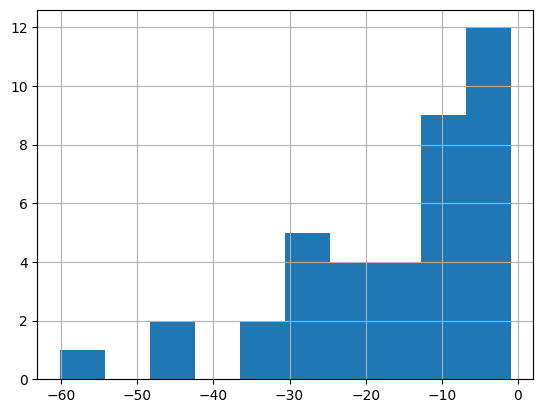

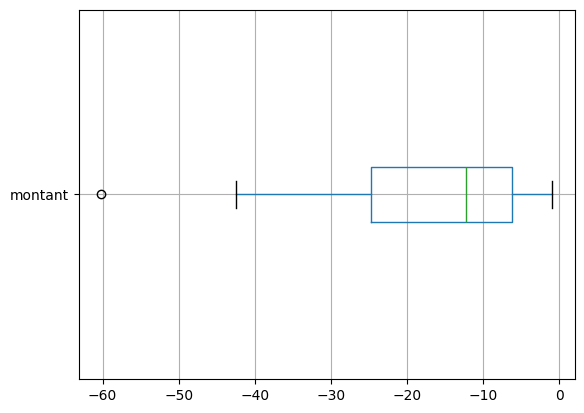

COTISATION BANCAIRE
La moyenne est :  -1.8857142857142857
La mediane est :  -1.92
Le mode est :  0   -1.92
Name: montant, dtype: float64
La variance est :  0.0015673469387755044
L ecart type est :  0.03958973274443141
L asymétrie est :  0.37416573867739106
L aplatissement est :  -2.800000000000003


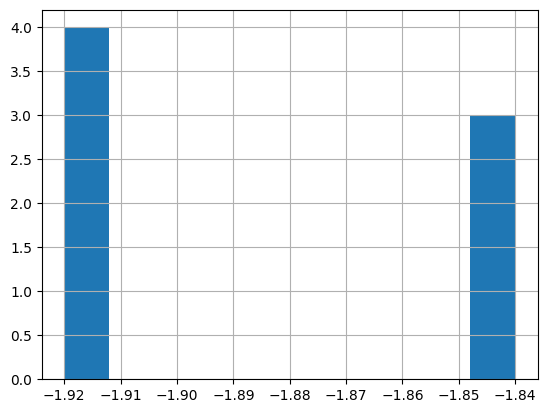

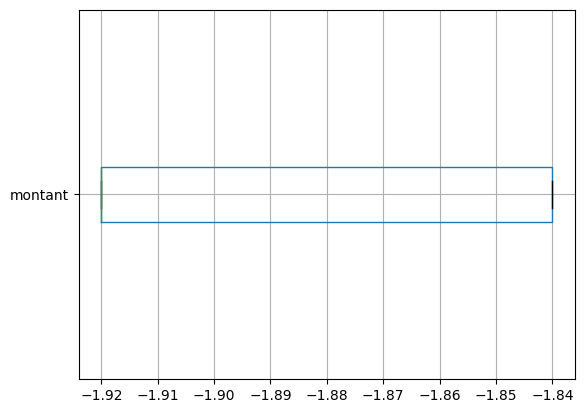

RESTAURANT
La moyenne est :  -10.3325
La mediane est :  -10.1
Le mode est :  0   -9.2
Name: montant, dtype: float64
La variance est :  2.853193750000001
L ecart type est :  1.689139943876765
L asymétrie est :  -0.8883503487158837
L aplatissement est :  0.5988855591691937


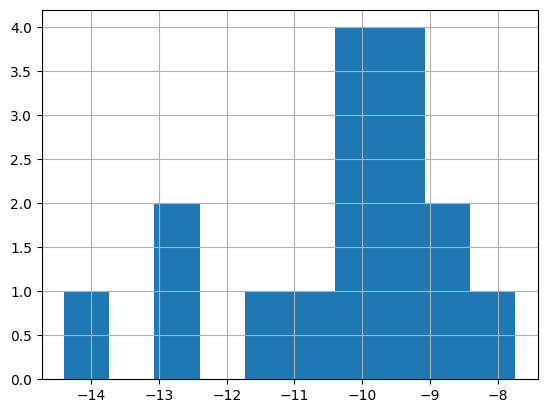

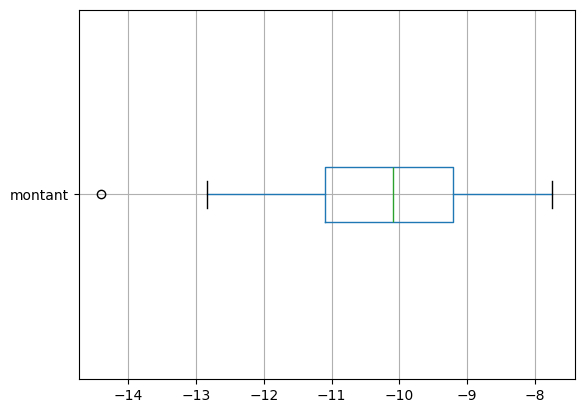

LOYER
La moyenne est :  -345.0
La mediane est :  -345.0
Le mode est :  0   -345.0
Name: montant, dtype: float64
La variance est :  0.0
L ecart type est :  0.0
L asymétrie est :  0.0
L aplatissement est :  0.0


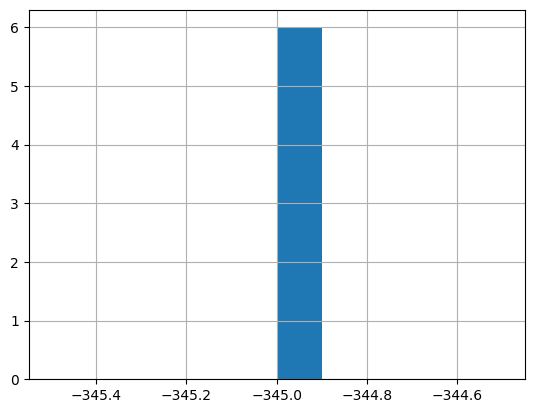

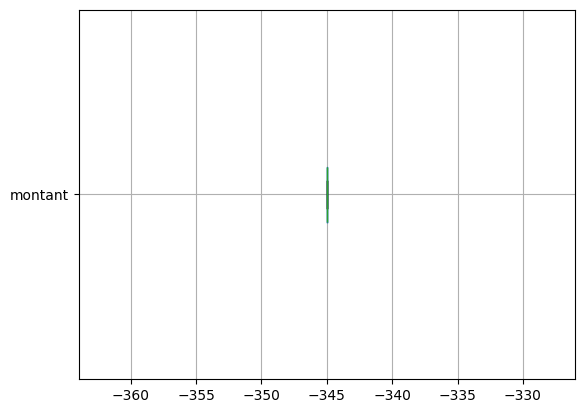

In [144]:
#Analyse de la variable montant par categorie d'operation ajouts des mesures de forme
for cat in data['categ'].unique():
  print(cat)
  print('La moyenne est : ', data[data['categ'] == cat]['montant'].mean())
  print('La mediane est : ', data[data['categ'] == cat]['montant'].median())
  print('Le mode est : ', data[data['categ'] == cat]['montant'].mode())
  print('La variance est : ', data[data['categ'] == cat]['montant'].var(ddof=0))
  print('L ecart type est : ', data[data['categ'] == cat]['montant'].std(ddof=0))
  print('L asymétrie est : ', data[data['categ'] == cat]['montant'].skew())
  print('L aplatissement est : ', data[data['categ'] == cat]['montant'].kurtosis())  #excès de kurtosis avec fisher = True donc on compare à 0
  data[data['categ'] == cat]['montant'].hist()
  plt.show()
  data[data['categ']==cat].boxplot(column='montant', vert = False)
  plt.show()

####INTERPRETATION DES MESURES DE FORMES AJOUTEES A CHAQUE CATEGORIE

- AUTRES : l'asymétrie positive très élevée (3.12) confirme la présence beaucoup plus fréquentes de valeurs extrêmes élevées qui tirent la moyenne vers le haut. L'excès de kurtosis (12.71) également très élevé indique une distribution leptokurtique avec des queues très lourdes et des valeurs extrêmes très fréquentes comparée à la distribution de la loi normale.
En résumé, les depenses AUTRES sont très imprévisibles et sujettes à des fluctuations importantes.  
%Confirmation de valeurs extremes %imprevisibilité %categorie à haut risque

- TRANSPORT : l'asymétrie négative (-1.25) signifie que la distribution des dépenses de transport a une queue plus longue à gauche confirmant la présence de valeurs basses plus fréquentes que les valeurs élevées (Dans notre cas un seul outlier à -190).
L'excès de kurtosis (2.19) positif indique une distribution leptokurtique avec des queues plus lourdes et la présence de valeurs extremes plus fréquentes par comparaison à la distribution normale.
En résumé, la distribution des dépenses de transport  est sujette à des dépenses basses fréquentes, mais en comparant l'intensité de l'excès, cette catégorie est moins volatile que la catégorie AUTRES.
%Confirmation de valeurs extremes faibles %Distribution moin extrême %Variabilité modérée

- FACTURE TELEPHONE : l'asymétrie de -2.39 est fortement négative. Cela signifie que la distribution des dépenses de factures de téléphone a une queue très longue à gauche, attestant la présence de valeurs extrêmes faibles plus fréquentes que les valeurs extrêmes élevées (Dans notre cas un seul outlier à -36.48), tirant la moyenne vers le bas. Le kurtosis quant à lui élévé (5.80) indique une distribution leptokurtique. Cela signifie que la distribution des dépenses de factures de téléphone a des queues plus lourdes et plus de valeurs extrêmes que la distribution normale. En résumé, ces dépenses sont sujettes à des fluctuations bien que ces fluctuations soient principalement des outliers faibles.
%Confirmation de valeurs extremes faibles %Distribution avec valeur extrême %Variabilité modérée

- COURSES : l'asymétrie négative (-1.25) signifie que la distribution des dépenses de courses a une queue plus longue à gauche prouvant la présence de valeurs extrêmes faibles plus fréquentes que les extrêmes élevées (Dans notre cas un seul outlier à -60.16) qui tirent la moyenne vers le bas. Le kurtosis de 1.6 indique une distribution leptokurtique avec des queues plus lourdes et plus d'outliers que la normale, mais moins intense que pour la catégorie FACTURE TELEPHONE (en comparant les valeurs de kurtosis).
Cette catégorie est sujette à des dépenses basses fréquentes et est moins volatile que la catégorie précédente

- COTISATION BANCAIRE : l'asymétrie légèrement positive de 0.37 indique que la distribution des cotisations bancaires est légèrement asymétrique, avec une légère queue plus longue à droite attestant la présence de quelques valeurs légèrement supérieures à la moyenne, mais ces valeurs ne sont pas extrêmes (pour preuve, nous n'avons pas d'outliers dans cette catégorie). Le kurtosis fortement négatif de -2.8 indique une distribution platykurtique très aplatie comparée à la normale : moins d'outliers que la distribution normale.
La combinaison d'une asymétrie légère et d'un excès de kurtosis négatif élevé indique une distribution très concentrée autour de la moyenne.
%Confirmation de la stabilité %absence de valeurs extrêmes %distribution très concentrée

- RESTAURANT : l'asymétrie négative de -0.89 indique que la distribution des dépenses au restaurant a une légère queue à gauche confirmant la présence plus fréquente d'outliers bas que d'outliers élevés (un outlier à -14.4). Le kurtosis légèrement positif de 0.6 indique une distribution légèrement leptokurtique : queues plus lourde que la normale et les valeurs extrèmes plus fréquentes que pour la normale : légère fluctuation extrème que la loi normale
En résumé la distribution des dépenses au restau présente des outliers bas mais moins fréquents, au vu de l'intensité faible du kurtosis.

- LOYER : l'asymétrie nulle indique une symétrie parfaite de la distribution des dépenses en loyer. L'excès de kurtosis nul indique une distribution parfaitement normale (mésokurtique), sans aucune valeur extrême.
La combinaison d'une asymétrie nulle et d'un excès de kurtosis nul indique une distribution parfaitement stable et prévisible.
%Confirmation de la constance %absence de valeur extreme %distribution parfaitement stable et prévisible

#Analyse bivariée

##Deux Variables quantitatives

On veut étudier la corrélation entre le solde avant opération et le montant des dépenses pour répondre à la question : y a t'il plus de dépenses lorsqu'on a plus d'argent dans le compte ? ou vis versa ?



###Representations Graphiques

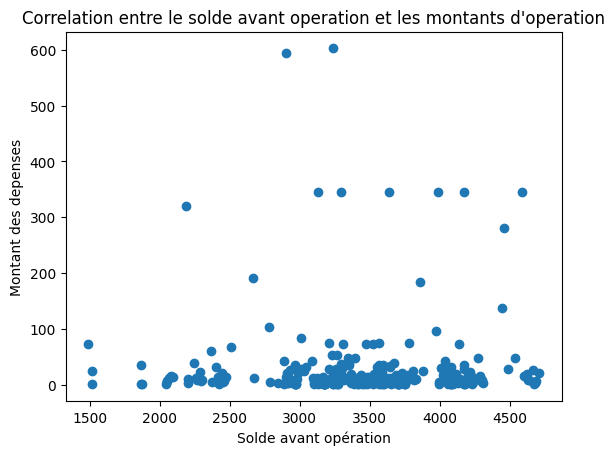

In [145]:
#Recuperer les données de depenses
depenses = data[data['montant'] < 0]     #recuperer les montants qui sont des dépenses

#nuage de point entre le solde avant operation et les montants d'operation
plt.scatter(depenses['solde_avt_ope'], -depenses['montant'])
plt.xlabel('Solde avant opération')
plt.ylabel('Montant des depenses')
plt.title("Correlation entre le solde avant operation et les montants d'operation")
plt.show()

Ce nuage de point ne nous permet pas de voir clairement la correlation entre les deux variables. Pour avoir une representation plus efficace, il est possible d'agréger la variable solde avant opération en differentes classes. On represente pour chaque tranche une boîte à moustache calculée à partir de tous les points présents dans la tranche.

In [146]:
#taille des classes pour la discrétisation
taille_classe = 500
#liste qui reçoit les données agregées à afficher
groupes = []
#tranches allant de 0 à la valeur max de solde avant operation par palier de 500
tranches = np.arange(0, max(depenses['solde_avt_ope']), taille_classe)
#on decale les tranches d'une demi taille de classe
tranches = tranches + taille_classe/2
#associe chaque solde à son numero de classe
indice_classe = np.digitize(depenses['solde_avt_ope'], tranches)

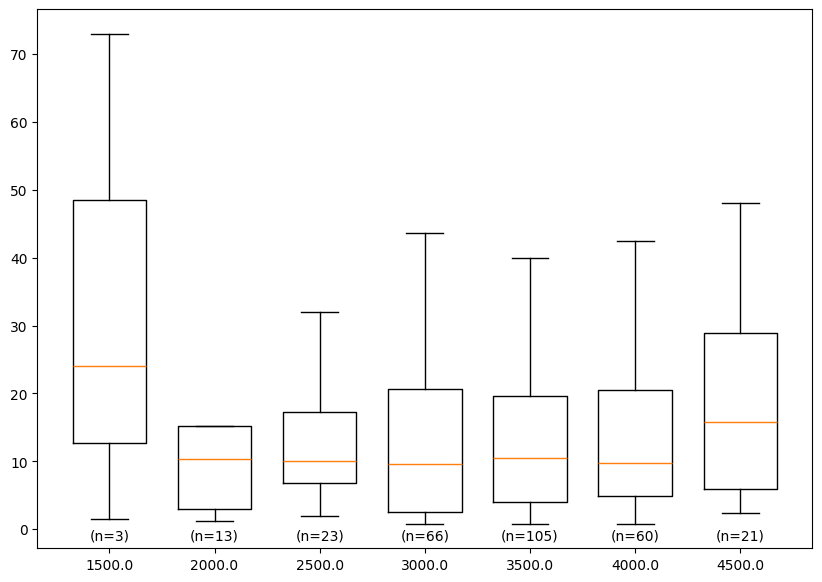

In [147]:
#pour chaque tranche, ind reçoit le num de la tranche et tr la tranche
for ind, tr in enumerate(tranches):
  #selection des individus de la tranche ind
  montants = -depenses.loc[indice_classe==ind, "montant"]
  if len(montants) > 0:
        g = {
            'valeurs': montants,
            'centre_classe': tr-(taille_classe/2),
            'taille': len(montants),
            'quartiles': [np.percentile(montants,p) for p in [25,50,75]]
        }
        groupes.append(g)

plt.figure(figsize=(10,7))

# affichage des boxplots
plt.boxplot([g["valeurs"] for g in groupes],
            positions= [g["centre_classe"] for g in groupes], # abscisses des boxplots
            showfliers= False, # on ne prend pas en compte les outliers
            widths= taille_classe*0.7) # largeur graphique des boxplots

# affichage des effectifs de chaque classe
for g in groupes:
    plt.text(g["centre_classe"],0,"(n={})".format(g["taille"]),horizontalalignment='center',verticalalignment='top')
plt.show()

###Calcul des indicateurs

In [148]:
#Calcul de la correlation entre le solde_avt_ope et les montants d'ope
correlation = depenses['solde_avt_ope'].corr(-depenses['montant'])
#Calcul de la covariance
covariance = np.cov(depenses["solde_avt_ope"],-depenses["montant"],ddof=0)[1,0]
#Affichage des 2 indicateurs
correlation, covariance


(np.float64(0.010068819133759198), np.float64(484.95954154532814))

Pour compléter numériquement les analyses, nous avons calculé les indicateurs.
La correlation de Pearson à 0.01 nous montre qu"il n'y a pas de correlation linéaire entre nos deux variables soldes avant opération et montants des opérations.

###Analyse de deux variables quantitatives par regression lineaire

On veut réaliser une analyse bivariée entre deux variables quantitatives que sont le montant d'un achat dans la catégorie courses  et le temps d'attente entre cet achat et le précedent achat de la catégorie course.
L'objectif est de savoir si le temps entre deux courses influe sur le montant dépensé lors de la deuxième course; soit est ce qu'on dépense plus lorsqu'on met du temps à faire des courses ?

Pour répondre à cette interrogation, nous allons procéder à la création d'un modèle de regression linéaire.

In [149]:
#Calculons la variable attente
import datetime as dt

# Selection du sous-échantillon
courses = data[data.categ == "COURSES"]

# On trie les opérations par date
courses = courses.sort_values("date_operation")

# On ramène les montants en positif
courses["montant"] = -courses["montant"]

# calcul de la variable attente
r = []
last_date = dt.datetime.now()
for i,row in courses.iterrows():
    days = (row["date_operation"]-last_date).days
    if days == 0:
        r.append(r[-1])
    else:
        r.append(days)
    last_date = row["date_operation"]
courses["attente"] = r
courses = courses.iloc[1:,]

# on regroupe les opérations qui ont été effectués à la même date
# (courses réalisées le même jour mais dans 2 magasins différents)
a = courses.groupby("date_operation")["montant"].sum()
b = courses.groupby("date_operation")["attente"].first()
courses = pd.DataFrame({"montant":a, "attente":b})
#le sous echantillon courses qui ne contient que les opérations de la catégorie COURSES
courses

,montant,attente
date_operation,,
2023-04-10,42.42,5
2023-04-25,32.67,15
2023-04-26,1.90,1
2023-04-28,9.11,2
2023-05-02,12.24,4
2023-05-04,17.16,2
2023-05-05,3.48,1
2023-05-10,42.45,5
2023-05-15,46.51,5


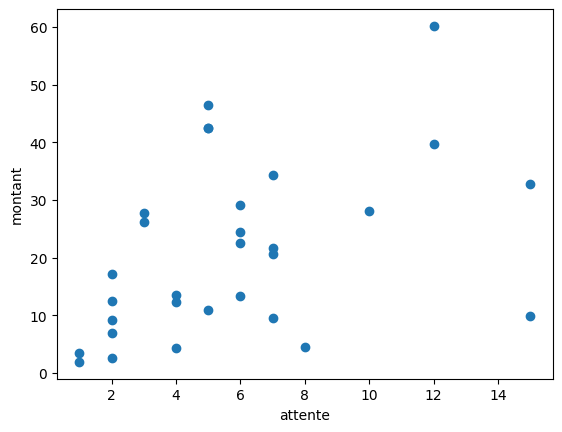

In [150]:
#Affichage du diagramme de dispersion avec en abscisse X la variable quantitative attente et en ordonné Y la variable quantitative montant
plt.plot(courses['attente'],courses['montant'], "o")
plt.xlabel("attente")
plt.ylabel("montant")
plt.show()

In [151]:
#Estimation des paramètres a et b
import statsmodels.api as sm
Y = courses['montant']
X = courses[['attente']]
X['intercept'] = 1
model = sm.OLS(Y, X)  # OLS = Ordinary Least Square (Moindres Carrés Ordinaire)
results = model.fit()
#print(results.summary())
a,b = results.params['attente'],results.params['intercept']
a,b

(np.float64(1.7365779467680615), np.float64(10.944847908745249))

####Interpretation
Donc dans notre cas :
a est estimé à 1.74 et
b à 10.94
soit on depense 1.74€ par jour et 10.94 pour le stock

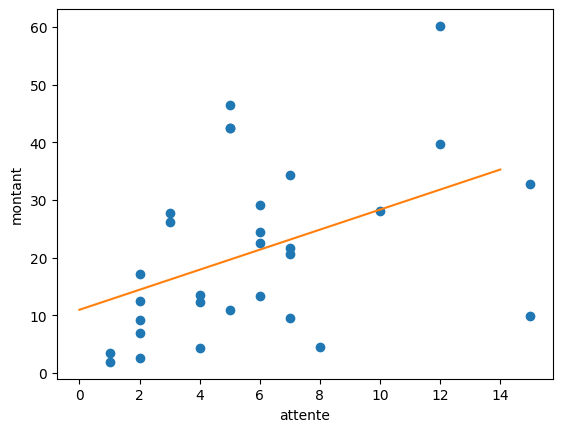

In [152]:
#Tracer la droite de regression
plt.plot(courses.attente,courses.montant, "o")
plt.plot(np.arange(15),[a*x+b for x in np.arange(15)])
plt.xlabel("attente")
plt.ylabel("montant")
plt.show()

####Regression linéaire sans les outliers
Supposons que les habitudes de consommations du client lui permettent d'affirmer qu'en général, il ne met pas 15 jours d'attente entre deux courses et que ces cas sont dû à un retour de vacance.
Nous sommes donc face à deux outliers que nous retirons de notre estimation.

In [153]:
#ReEstimation des paramètres a et b
#import statsmodels.api as sm
courses = courses[courses.attente < 15]
Y = courses['montant']
X = courses[['attente']]
X['intercept'] = 1
model = sm.OLS(Y, X)  # OLS = Ordinary Least Square (Moindres Carrés Ordinaire)
results = model.fit()
#print(results.summary())
a_new,b_new = results.params['attente'],results.params['intercept']
a_new,b_new

(np.float64(3.030823389021477), np.float64(5.411479713603832))

####Interpretation
Ce cas est bien plus réaliste :
a est estimé à 3.03 et
b à 5.41
soit on depense 3.03€ par jour et 5.41 pour le stock

Par contre on remarque que les resultats sont trop differents; en effet, seulement 2 points ecartés changent carrément la droite de regression. En conclusion, la régression linéaire avec estimation par la méthode des moindres carrés est peu robuste aux outliers.

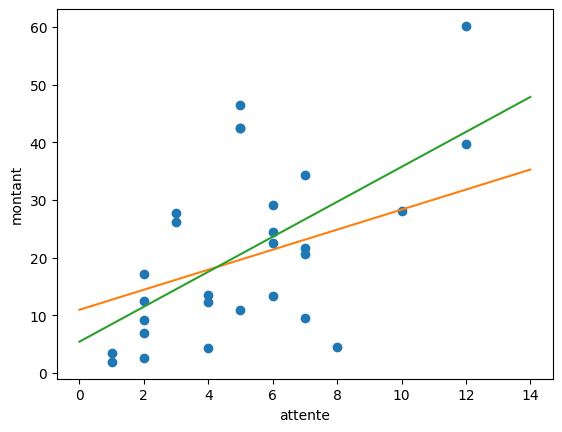

In [154]:
#Tracer la nouvelle droite de regression
plt.plot(courses.attente,courses.montant, "o")
plt.plot(np.arange(15),[a*x+b for x in np.arange(15)])
plt.plot(np.arange(15),[a_new*x+b_new for x in np.arange(15)])
plt.xlabel("attente")
plt.ylabel("montant")
plt.show()

## Une variable quantitative et une qualitative

Objectif : nous voulons savoir si le montant d'une opération diffère d'une categorie de dépense à une autre.
Pour le faire, on analyse donc les variables catégorie (qualitative) et montant (quantitative).

In [155]:
X = "categ" # qualitative
Y = "montant" # quantitative

# On ne garde que les dépenses
sous_echantillon = data.loc[data["montant"] < 0, :].copy()
# On remet les dépenses en positif
sous_echantillon["montant"] = -sous_echantillon["montant"]
# On n'étudie pas les loyers car trop gros:
#sous_echantillon = sous_echantillon.loc[sous_echantillon["categ"] != "LOYER", :]

###Representations graphiques

<ipython-input-156-68d6a90363e0>:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groupes, labels=modalites, showfliers=False, medianprops=medianprops,


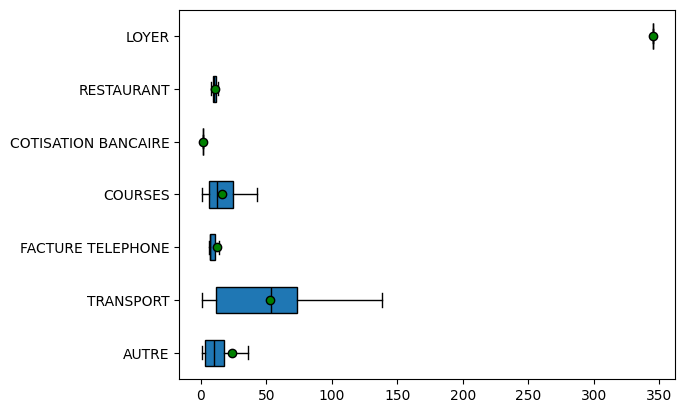

In [156]:
#Boxplot pour chaque catégorie de dépenses (modalités de la variable categ)
modalites = sous_echantillon[X].unique()
groupes = []
for m in modalites:
    groupes.append(sous_echantillon[sous_echantillon[X]==m][Y])

# Propriétés graphiques (pas très importantes)
medianprops = {'color':"black"}
meanprops = {'marker':'o', 'markeredgecolor':'black',
            'markerfacecolor':'green'}

plt.boxplot(groupes, labels=modalites, showfliers=False, medianprops=medianprops,
            vert=False, patch_artist=True, showmeans=True, meanprops=meanprops)
plt.show()

####Interpretation

La moyenne de chaque variable est representée par le markeur vert.
Le graphique nous permet de constater que le montant d'une opération diffère considérablement d'une categorie de dépense à une autre.
Les dépenses en transport sont plus élevées et ont une plus grande dispersion que les dépenses au restaurant et en courses par exemple.
Confirmation ou infirmation de notre observation par des tests statistiques.


###Test ANOVA

Pour analyser la relation entre une variable quantitative et une qualitative, l'un des tests les plus utilisés est l'ANOVA (ANalysis Of VAriance). L'ANOVA vise à déterminer s'il existe des différences statistiquement significatives entre les moyennes des modalités de la variable catégorielle.

In [157]:
pip install pingouin


In [158]:
#Test ANOVA avec le package pingouin
import pingouin as pg
resultat_anova = pg.anova(data=sous_echantillon, dv='montant', between='categ', effsize= 'np2')
resultat_anova

,Source,ddof1,ddof2,F,p-unc,np2
0,categ,6,284,31.348217,7.625917e-29,0.398419


In [159]:
import scipy.stats as stats
#OU ENCORE Fonction python pour l'ANOVA
fvalue, pvalue = stats.f_oneway(sous_echantillon['montant'][sous_echantillon['categ']=='COURSES'],
                                sous_echantillon['montant'][sous_echantillon['categ']=='TRANSPORT'],
                                sous_echantillon['montant'][sous_echantillon['categ']=='RESTAURANT'],
                                sous_echantillon['montant'][sous_echantillon['categ']=='COTISATION BANCAIRE'],
                                sous_echantillon['montant'][sous_echantillon['categ']=='FACTURE TELEPHONE'],
                                sous_echantillon['montant'][sous_echantillon['categ']=='AUTRE'],
                                sous_echantillon['montant'][sous_echantillon['categ']=='LOYER'])
fvalue, pvalue

(np.float64(31.348217082597326), np.float64(7.625916646832278e-29))

In [160]:
# prompt: comment interpreter la p value de 7.69e-29 pour l'ANOVA

#Une p-value de 7.69e-29, extrêmement faible (inférieure à 0.05, seuil de signification classique), indique une très forte évidence statistique
# pour rejeter l'hypothèse nulle de l'ANOVA.  L'hypothèse nulle stipule que les moyennes des populations des groupes définis par la variable
#catégorielle ("categ" dans votre cas) sont toutes égales.

#En d'autres termes,  la différence observée dans les dépenses moyennes entre les différentes catégories de dépenses n'est pas due au hasard.
# Il existe une différence significative entre au moins deux des catégories de dépenses.  L'ANOVA confirme l'observation visuelle du boxplot
#montrant des moyennes différentes pour les dépenses selon la catégorie.


In [161]:
#Calcul de eta squared à la main

def eta_squared(x,y):
    moyenne_y = y.mean()
    classes = []
    for classe in x.unique():
        yi_classe = y[x==classe]
        classes.append({'ni': len(yi_classe),
                        'moyenne_classe': yi_classe.mean()})
    SCT = sum([(yj-moyenne_y)**2 for yj in y])
    SCE = sum([c['ni']*(c['moyenne_classe']-moyenne_y)**2 for c in classes])
    return SCE/SCT

eta_squared(sous_echantillon[X],sous_echantillon[Y])

np.float64(0.39841890401094926)

In [162]:
# prompt: comment interpreter le eta squared de 0.39

#Un eta carré de 0.39 indique une taille d'effet moyenne à forte. Cela signifie que la variable catégorielle (categ) explique 39% de la
#variance de la variable quantitative (montant).  En d'autres termes, la catégorie de dépense a un impact substantiel sur le montant dépensé.
#Plus précisément, les différences observées entre les moyennes des montants des différentes catégories de dépenses ne sont pas dues au hasard,
#et représentent une part importante de la variabilité totale des données.


####Interpretation

Le test de l'ANOVA réalisé entre le montant des dépenses et les catégories de dépense montre bien qu'il existe un lien entre les montants et les catégories de dépenses, en d'autres termes, le montant dépensé dépend de la catégorie de dépense. Exemple : les dépenses en loyer et transport sont bien plus importantes que les dépenses en cotisation bancaire et en facture téléphonique.
Ce lien est statistiquement significatif.
Eta carré mesure la force de l'association ou de la relation entre les variables.

###Test ANOVA sur d'autres données

Objectif : on veut analyser la relation entre le montant des depenses et la periode dans le mois où sont effectuées ces dépenses. L'idée est de savoir si certains jours du mois sont plus propices à la depense que d'autres. On analyse donc les variables quart_mois (qualitative) et montant (quantitative)

<ipython-input-163-8433f67ab911>:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groupes, labels=modalites, showfliers=False, medianprops=medianprops,


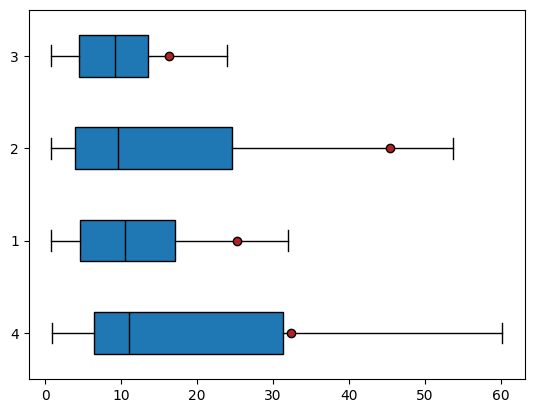

In [163]:
X = "quart_mois" # qualitative
Y = "montant" # quantitative

modalites = sous_echantillon[X].unique()
groupes = []
for m in modalites:
    groupes.append(sous_echantillon[sous_echantillon[X]==m][Y])

# Propriétés graphiques (pas très importantes)
medianprops = {'color':"black"}
meanprops = {'marker':'o', 'markeredgecolor':'black',
            'markerfacecolor':'firebrick'}

plt.boxplot(groupes, labels=modalites, showfliers=False, medianprops=medianprops,
            vert=False, patch_artist=True, showmeans=True, meanprops=meanprops)
plt.show()

In [164]:
#Test ANOVA
resultat_anova = pg.anova(data=sous_echantillon, dv='montant', between='quart_mois', effsize= 'np2')
resultat_anova

,Source,ddof1,ddof2,F,p-unc,np2
0,quart_mois,3,287,2.004107,0.113546,0.020519


In [165]:
#Verification eta squared
eta_squared(sous_echantillon[X],sous_echantillon[Y])

np.float64(0.02051900845520141)

In [166]:
# prompt: comment interpreter la p value de 0.11 pour l'ANOVA et 0.02 pour le eta squared

# Interprétation de la p-value de l'ANOVA et de eta squared

# p-value de l'ANOVA (0.11)
# L'hypothèse nulle de l'ANOVA est qu'il n'y a pas de différence significative entre les moyennes des groupes.
# Une p-value de 0.11 est supérieure au seuil de signification classique de 0.05.
# Par conséquent, nous ne pouvons pas rejeter l'hypothèse nulle.  Cela signifie que les données ne fournissent pas suffisamment
#de preuves pour conclure qu'il existe une différence significative entre les moyennes des groupes.  En d'autres termes, les variations
#observées entre les groupes pourraient être dues au hasard.


# Eta squared (0.02)
# Eta squared mesure la taille de l'effet, c'est-à-dire la proportion de variance de la variable dépendante expliquée par la variable indépendante.
# Une valeur de 0.02 indique une faible taille d'effet.
# Cela signifie que la variable indépendante (la variable catégorielle dans votre ANOVA) explique seulement 2% de la variabilité de la variable
#dépendante (le montant dans votre cas).
# Bien que l'ANOVA n'ait pas révélé de différence significative entre les moyennes des groupes (en raison de la p-value > 0.05), eta squared
#nous indique que même s'il y avait une différence, l'impact de la variable catégorielle sur le montant serait faible.

# En résumé : malgré une différence moyenne apparente entre les groupes, l'ANOVA ne permet pas de rejeter l'hypothèse d'absence de différence
#significative entre les groupes de la variable 'categ'  et la taille de l'effet est faible.  D'autres analyses ou des groupes plus distincts
#pourraient être nécessaires pour identifier des différences significatives.


##Deux variables qualitatives

Objectif : nous voulons savoir s'il y a des catégories d'opérations qui arrivent toujours au même moment du mois, comme le loyer, par exemple. Pour cela, nous analysons les variables categ (qualitative) et quart_mois (qualitative).

###Représentation

Pour analyser les relations entre deux variables qualitatives, on représentera les données par un tableau de contingence.
Une heatmap en plus permettra par exemple de représenter visuellement les élements contribuant au mieux à la relation entre ces variables.

In [169]:
#Tableau de contingence

X = "quart_mois"
Y = "categ"

Tableau_contingence = data[[X,Y]].pivot_table(index=X,columns=Y,aggfunc=len,margins=True,margins_name="Total")
Tableau_contingence

categ,AUTRE,COTISATION BANCAIRE,COURSES,FACTURE TELEPHONE,LOYER,RESTAURANT,TRANSPORT,Total
quart_mois,,,,,,,,
1,55.0,7.0,6.0,6.0,NaN,3.0,9.0,86
2,45.0,NaN,11.0,1.0,6.0,7.0,6.0,76
3,60.0,NaN,7.0,NaN,NaN,4.0,4.0,75
4,52.0,NaN,15.0,NaN,NaN,2.0,2.0,71
Total,212.0,7.0,39.0,7.0,6.0,16.0,21.0,308


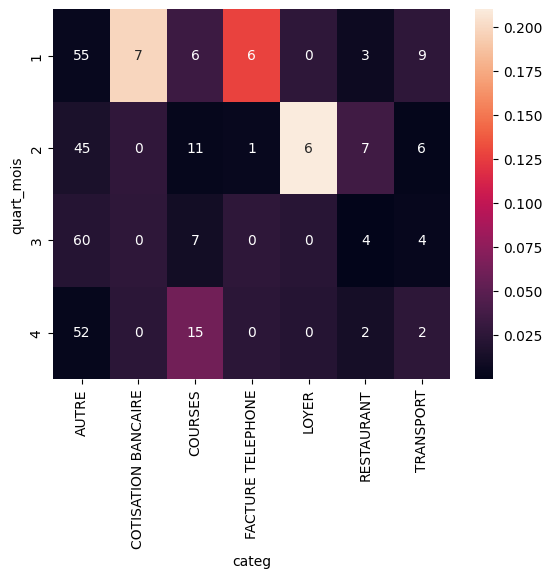

In [179]:
#Heatmap
tx = Tableau_contingence.loc[:,["Total"]]
ty = Tableau_contingence.loc[["Total"],:]
n = len(data)
indep = tx.dot(ty) / n

Tabl_cont = Tableau_contingence.fillna(0) # On remplace les valeurs nulles par 0
measure = (Tabl_cont-indep)**2/indep
xi_n = measure.sum().sum()
table = measure/xi_n
sns.heatmap(table.iloc[:-1,:-1],annot=Tabl_cont.iloc[:-1,:-1])
plt.show()

In [ ]:
# prompt: explique moi les lignes de code du bloc ci dessus (pour la heat map)

# This code snippet creates a heatmap to visualize the relationship between two categorical variables: "quart_mois" (quarter of the month) and "categ" (category of expense).

# 1. Contingency Table:
#    - `Tableau_contingence = data[[X,Y]].pivot_table(...)`: Creates a contingency table summarizing the counts of each combination of "quart_mois" and "categ".
#      - `index=X`, `columns=Y`: Specifies the row and column variables.
#      - `aggfunc=len`: Counts the occurrences of each combination.
#      - `margins=True`, `margins_name="Total"`: Adds row and column totals.
#    - `Tableau_contingence`: The resulting contingency table.

# 2. Heatmap Preparation:
#    - `tx`, `ty`: Calculate row and column totals.
#    - `n = len(data)`: Total number of data points.
#    - `indep = tx.dot(ty) / n`: Calculates the expected counts under the assumption of independence between the two variables.

# 3. Chi-Squared Measure:
#    - `Tabl_cont = Tableau_contingence.fillna(0)`: Replaces any missing values (NaN) in the contingency table with 0.
#    - `measure = (Tabl_cont-indep)**2/indep`: Calculates the contribution of each cell to the chi-squared statistic.
#    - `xi_n = measure.sum().sum()`: Total chi-squared statistic.
#    - `table = measure/xi_n`: Normalizes the chi-squared contributions to create a heatmap.

# 4. Heatmap Generation:
#    - `sns.heatmap(table.iloc[:-1,:-1], annot=Tabl_cont.iloc[:-1,:-1])`: Generates the heatmap.
#      - `table.iloc[:-1,:-1]`: Uses the normalized chi-squared contributions (excluding the total rows/columns) for the heatmap values.
#      - `annot=Tabl_cont.iloc[:-1,:-1]`: Annotates each cell with the observed counts.
#    - `plt.show()`: Displays the heatmap.

# In summary, this code visualizes the relationship between two categorical variables by creating a heatmap based on a chi-squared test.
#Cells with higher values (warmer colors) indicate a stronger association between the corresponding categories of "quart_mois" and "categ", relative to the expected counts under independence.


####Interpretation

Grâce à la heatmap, nous voyons qu'il y a une très forte liaison entre la modalité LOYER et la 2e SEMAINE DE CHAQUE MOIS et entre la modalité COTISATION BANCAIRE et la 1ere SEMAINE DE CHAQUE MOIS.
Tous les loyers sont payés pendant cette periode du mois (2e quart).
Les cotisations bancaires sont quant à elles payées pendant la premiere semaine du mois.

Le 2e niveau de relation est entre la modalité FACTURE TELEPHONE et la 1ere semaine du mois. Les factures de téléphone sont la plupart du temps payées dans cette periode.

###Test de Khi 2

In [178]:
# prompt: Si ensuite je veux appliquer un  test de khi deux, devrais-je l'appliquer sur table ou sur Tabl_cont ?

# You should apply the Chi-Square test to the 'observed' frequencies (the 'Tabl_cont' variable in your code).
# The 'table' variable you created for the heatmap is already normalized, so it shouldn't be used directly for the Chi-Square test.


In [181]:
# Effectuer le test du Khi-deux d'indépendance
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = stats.chi2_contingency(Tabl_cont.iloc[:-1,:-1])

# Afficher les résultats
print("Chi-deux statistic:", chi2_statistic)
print("P-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)
print("Expected frequencies:\n", expected_frequencies)

Chi-deux statistic: 65.66160586349196
P-value: 2.4137466118358207e-07
Degrees of freedom: 18
Expected frequencies:
 [[59.19480519  1.95454545 10.88961039  1.95454545  1.67532468  4.46753247
   5.86363636]
 [52.31168831  1.72727273  9.62337662  1.72727273  1.48051948  3.94805195
   5.18181818]
 [51.62337662  1.70454545  9.49675325  1.70454545  1.46103896  3.8961039
   5.11363636]
 [48.87012987  1.61363636  8.99025974  1.61363636  1.38311688  3.68831169
   4.84090909]]


####Interprétation
- La statistique du Chi-deux mesure la différence entre les fréquences observées et les fréquences attendues.
- La p-valeur indique la probabilité d'observer une telle différence (ou une différence plus extrême) si les variables
sont réellement indépendantes.
 - Une faible p-valeur (typiquement inférieure à 0.05) suggère que les variables ne sont PAS indépendantes et qu'il existe
une association statistiquement significative entre elles.
 - Les degrés de liberté représentent le nombre de valeurs indépendantes dans le tableau de contingence.
 - Les fréquences attendues sont les effectifs attendus si les variables étaient indépendantes.

La statistique du Chi-deux de 65,66 et une p-valeur de 2,41e-07 indiquent une association très forte entre les deux variables catégorielles «quart_mois» et «categ».

- La p-valeur extrêmement faible, bien inférieure au seuil de significativité commun de 0,05 fournit une preuve solide qu'il existe une association statistiquement significative entre la semainde du mois et la catégorie de dépenses.

- L'ampleur de la statistique du Chi-deux (65,66) indique la force de l'association. La valeur de 65,66 est assez élevée, ce qui soutient davantage la conclusion d'une association significative.
Conclusion :
L'analyse suggère fortement que la période du mois (représentée par « quart_mois ») est significativement liée au type de dépense (« categ »). Ceci confirme les observations faites dans la carte thermique (Heatmap), où certaines catégories de dépenses (comme le loyer et les frais bancaires) semblent être concentrées à des moments spécifiques du mois.


In [ ]:
#Projet inspiré du cours nettoyage et analyse de données de OpenClassroom